In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('./data/titanic_clean.csv')
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [4]:
print(f"El dataset limpio contiene {df.shape[0]} filas y {df.shape[1]} columnas.")


El dataset limpio contiene 891 filas y 8 columnas.


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


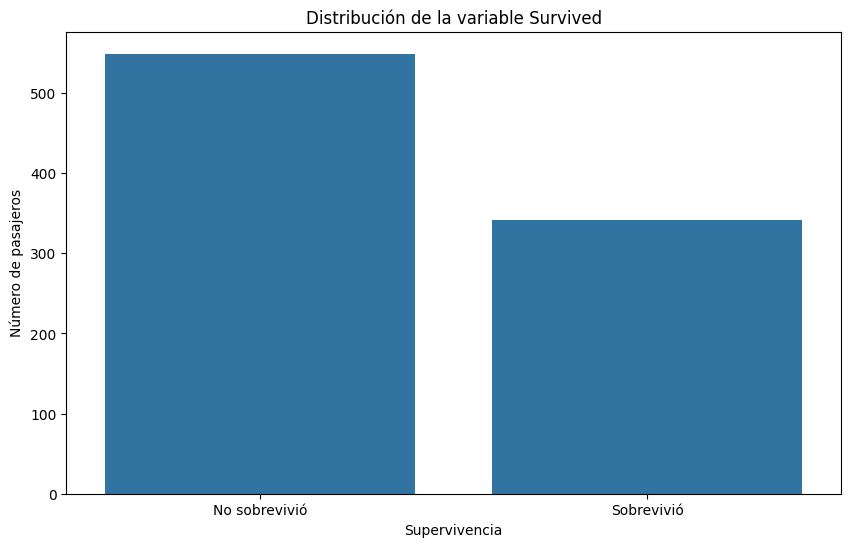

In [6]:
survived_counts = df['Survived'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=survived_counts.index, y=survived_counts.values)
plt.title('Distribución de la variable Survived')
plt.xlabel('Supervivencia')
plt.ylabel('Número de pasajeros')
plt.xticks([0, 1], ['No sobrevivió', 'Sobrevivió'])
plt.show()


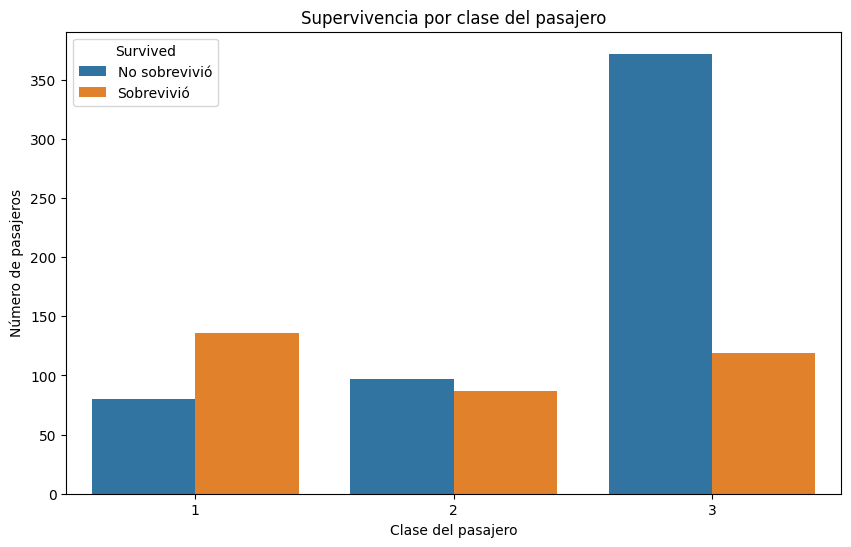

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Supervivencia por clase del pasajero')
plt.xlabel('Clase del pasajero')
plt.ylabel('Número de pasajeros')
plt.legend(title='Survived', labels=['No sobrevivió', 'Sobrevivió'])
plt.show()


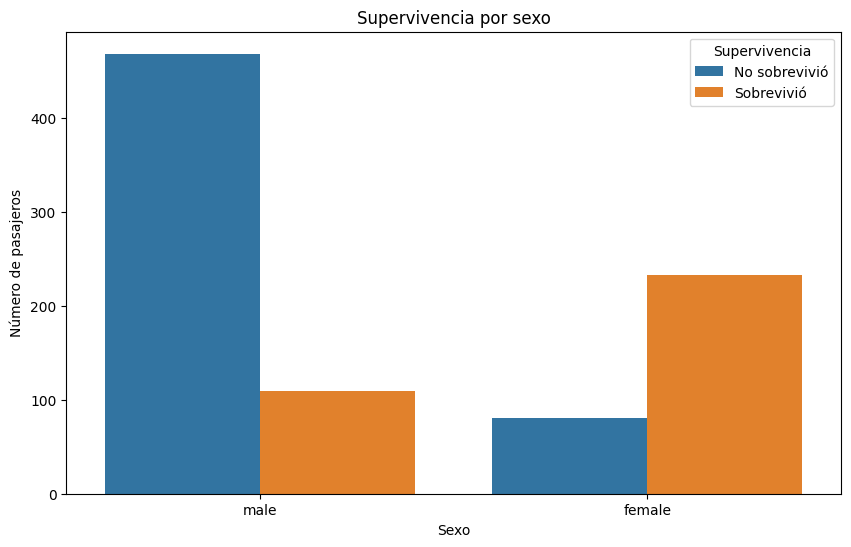

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Supervivencia por sexo')
plt.xlabel('Sexo')
plt.ylabel('Número de pasajeros')
plt.legend(title='Supervivencia', labels=['No sobrevivió', 'Sobrevivió'])
plt.show()


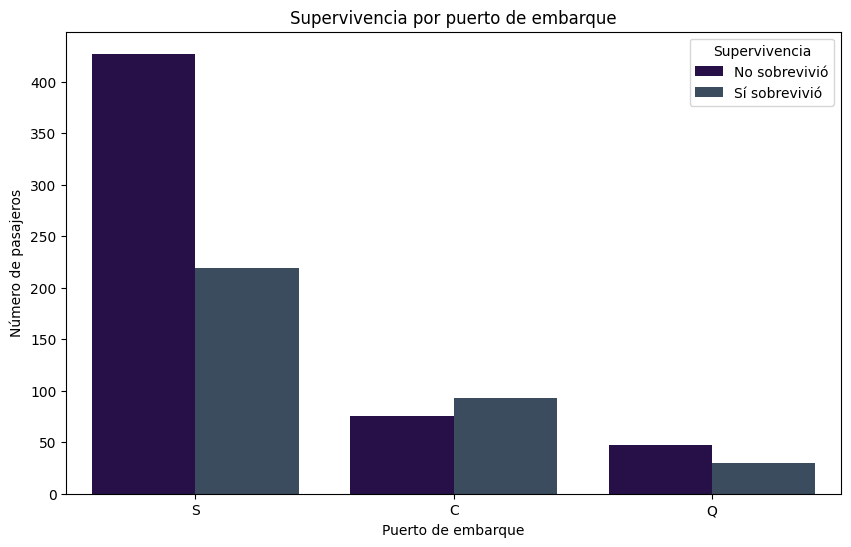

In [9]:
plt.figure(figsize=(10, 6))

colors = ['#240750', '#344C64']

sns.countplot(data=df, x='Embarked', hue='Survived', palette=colors)
plt.title('Supervivencia por puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Número de pasajeros')
plt.legend(title='Supervivencia', labels=['No sobrevivió', 'Sí sobrevivió'])
plt.show()


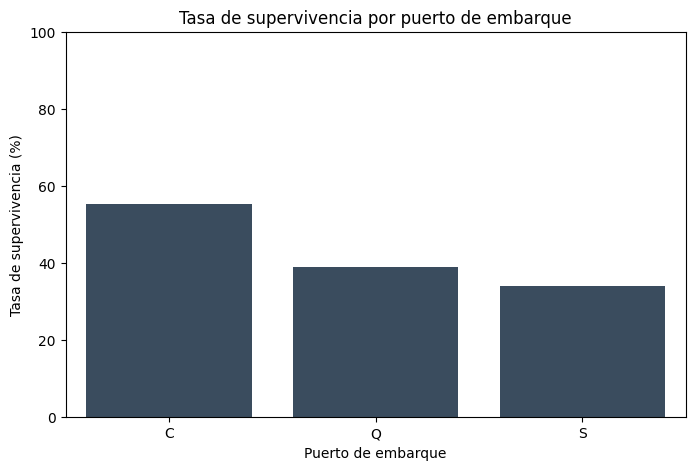

In [10]:
survival_by_embarked = (df.groupby('Embarked')['Survived'].mean() * 100).round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=survival_by_embarked.index, y=survival_by_embarked.values, color='#344C64')
plt.title('Tasa de supervivencia por puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Tasa de supervivencia (%)')
plt.ylim(0, 100)
plt.show()


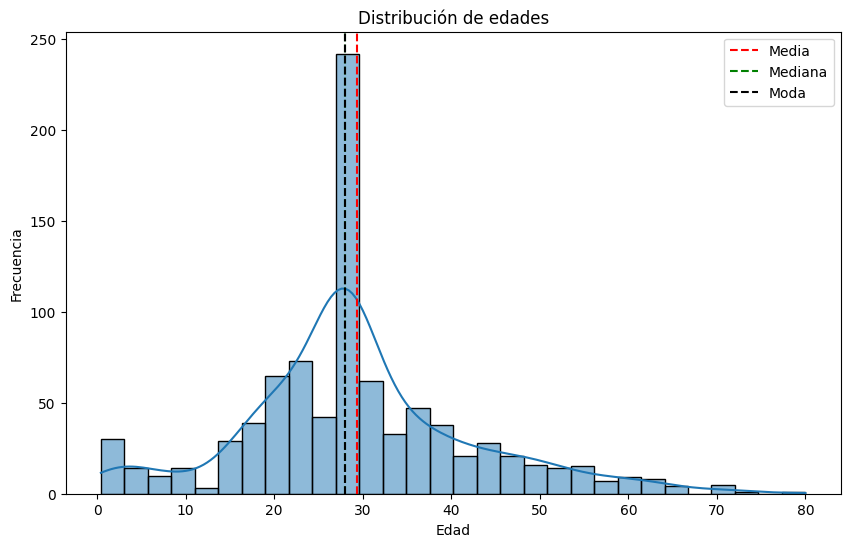

Media: 29.36
Mediana: 28.00
Moda: 28.00


In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='Age', kde=True)
plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Media')
plt.axvline(df['Age'].median(), color='green', linestyle='--', label='Mediana')
plt.axvline(df['Age'].mode()[0], color='black', linestyle='--', label='Moda')

plt.legend()
plt.show()

print(f"Media: {df['Age'].mean():.2f}")
print(f"Mediana: {df['Age'].median():.2f}")
print(f"Moda: {df['Age'].mode()[0]:.2f}")


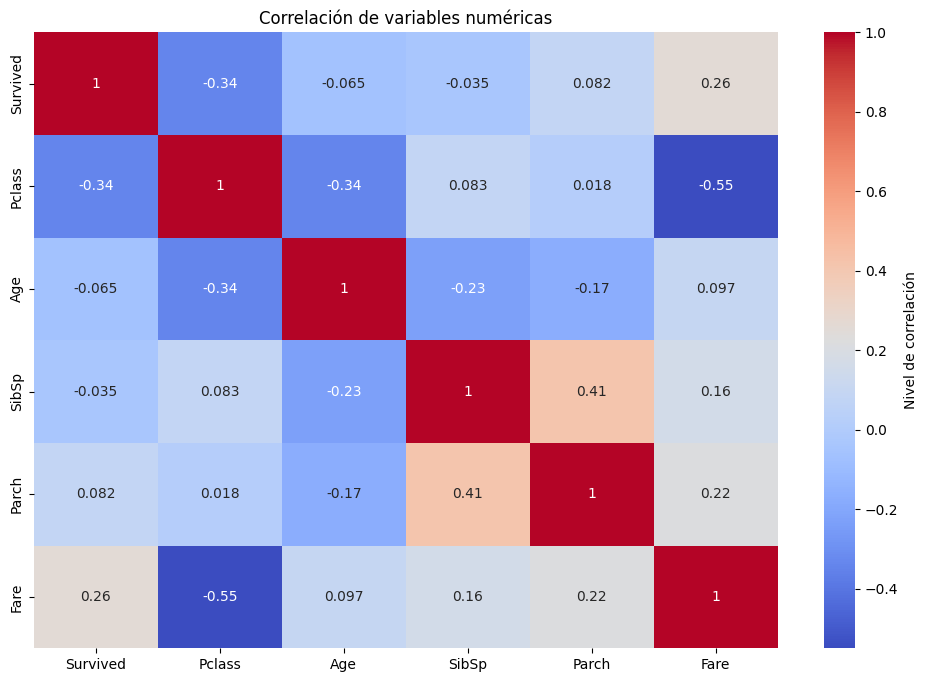

In [12]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,
            cmap='coolwarm',
            cbar_kws={'label': 'Nivel de correlación'})
plt.title('Correlación de variables numéricas')
plt.show()


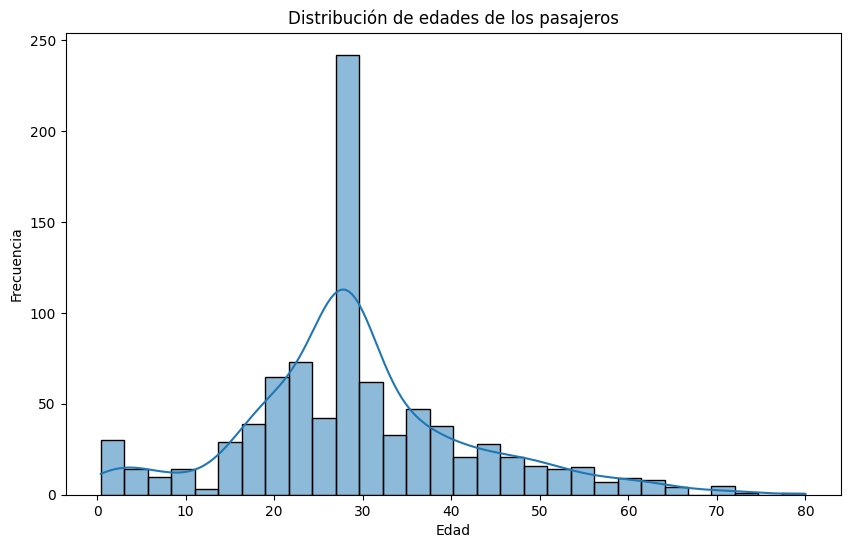

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', kde=True)
plt.title('Distribución de edades de los pasajeros')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

**Análisis.** La distribución de edades muestra que la mayor concentración de pasajeros se encuentra entre los 20 y 35 años. La edad mínima registrada es de 0.42 años y la máxima de 80 años, por lo que el rango es bastante amplio. En general, el conjunto está dominado por jóvenes adultos.

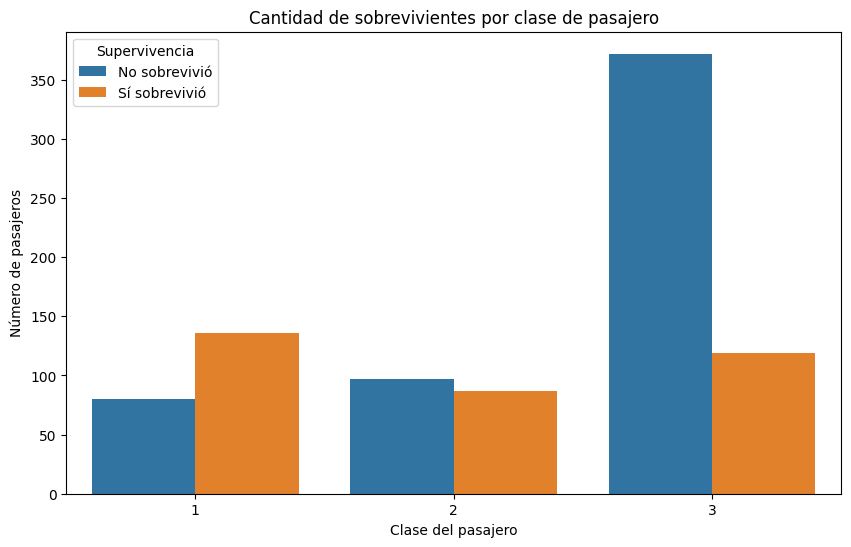

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Cantidad de sobrevivientes por clase de pasajero')
plt.xlabel('Clase del pasajero')
plt.ylabel('Número de pasajeros')
plt.legend(title='Supervivencia', labels=['No sobrevivió', 'Sí sobrevivió'])
plt.show()


**Análisis.** La gráfica muestra una relación clara entre la clase del pasajero y la supervivencia. En primera clase sobrevivieron 136 pasajeros frente a 80 fallecidos, mientras que en tercera clase sobrevivieron solo 119 frente a 372 fallecidos. Esto sugiere que viajar en una clase más alta aumentó notablemente la probabilidad de sobrevivir.

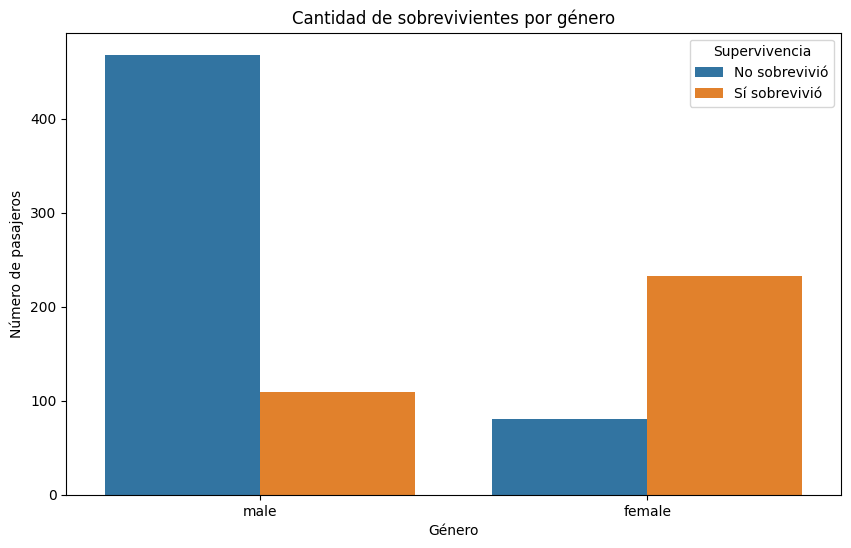

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Cantidad de sobrevivientes por género')
plt.xlabel('Género')
plt.ylabel('Número de pasajeros')
plt.legend(title='Supervivencia', labels=['No sobrevivió', 'Sí sobrevivió'])
plt.show()


**Análisis.** Se observa una diferencia muy marcada por género. Entre las mujeres sobrevivieron 233 y fallecieron 81, mientras que entre los hombres sobrevivieron 109 y fallecieron 468. Este patrón indica que el sexo fue una de las variables más influyentes en la supervivencia.

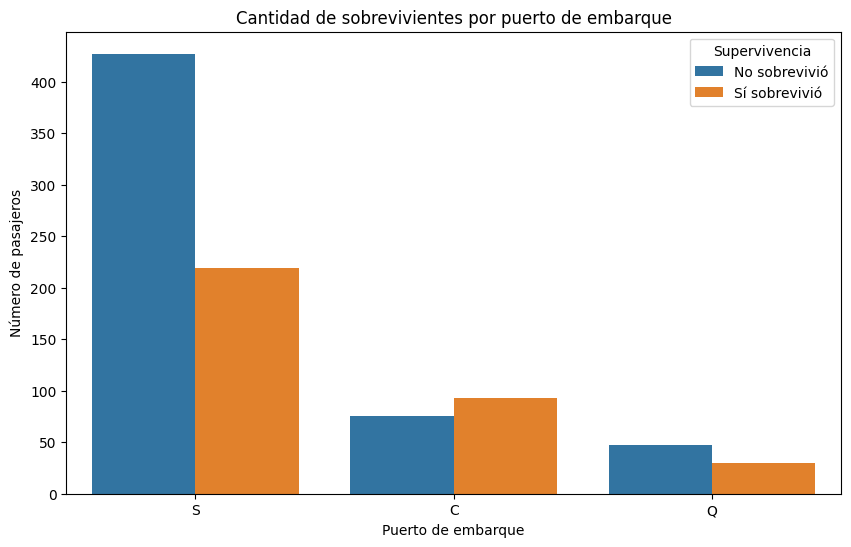

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Embarked', hue='Survived')
plt.title('Cantidad de sobrevivientes por puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Número de pasajeros')
plt.legend(title='Supervivencia', labels=['No sobrevivió', 'Sí sobrevivió'])
plt.show()


**Análisis.** Southampton (`S`) concentra la mayor cantidad de pasajeros y también el mayor número de fallecidos. Sin embargo, al comparar proporciones, Cherbourg (`C`) presenta un mejor comportamiento de supervivencia que `Q` y `S`. Esto sugiere que el puerto de embarque podría estar relacionado indirectamente con otras variables como la clase del pasajero.

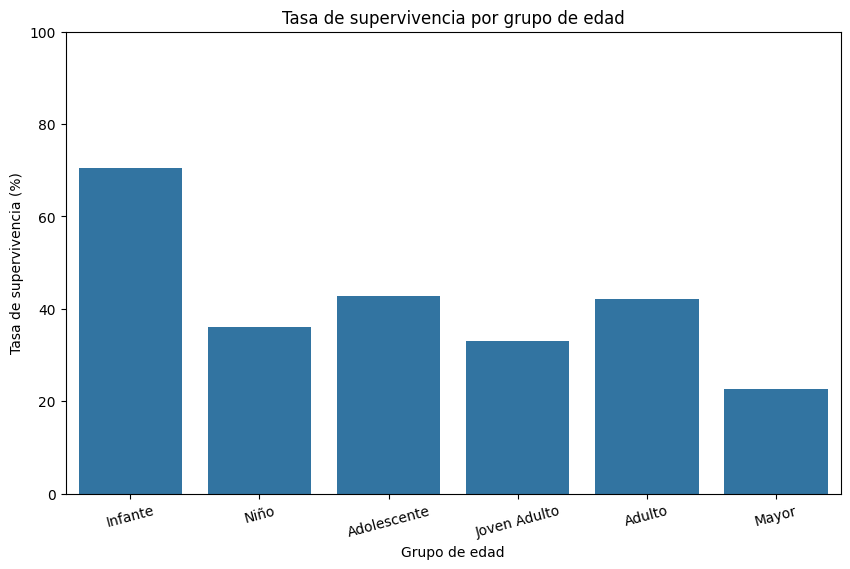

In [17]:
bins = [0, 5, 12, 18, 30, 60, 100]
labels = ['Infante', 'Niño', 'Adolescente', 'Joven Adulto', 'Adulto', 'Mayor']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

survival_by_agegroup = df.groupby('AgeGroup', observed=False)['Survived'].mean() * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=survival_by_agegroup.index, y=survival_by_agegroup.values)
plt.title('Tasa de supervivencia por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Tasa de supervivencia (%)')
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.show()


**Análisis.** Al agrupar las edades, el grupo con mayor tasa de supervivencia es el de los infantes, con 70.45%, seguido por los adolescentes con 42.86% y los adultos con 42.05%. Los mayores presentan la tasa más baja, con 22.73%. Esto sugiere que la edad sí influyó en la probabilidad de sobrevivir, especialmente en los extremos etarios.

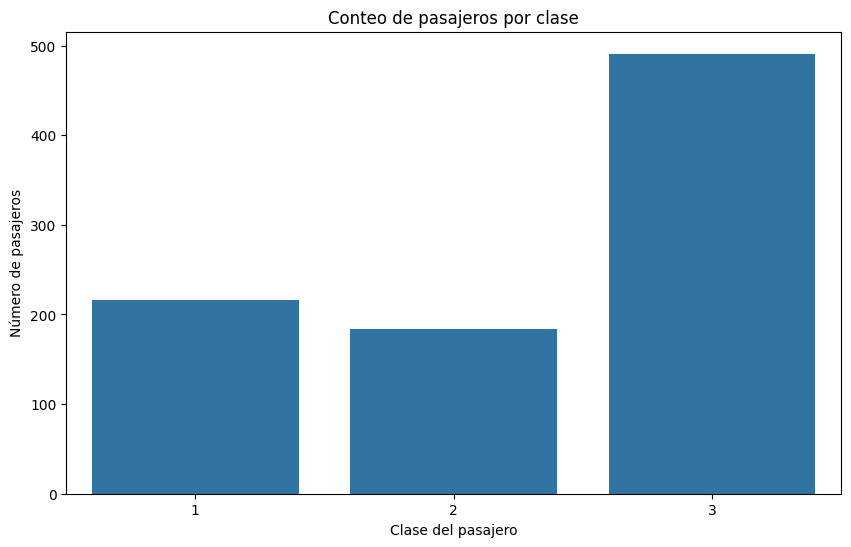

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Pclass')
plt.title('Conteo de pasajeros por clase')
plt.xlabel('Clase del pasajero')
plt.ylabel('Número de pasajeros')
plt.show()


**Análisis.** La mayoría de los pasajeros pertenecía a tercera clase, con 491 registros, seguida por primera clase con 216 y segunda clase con 184. Esto indica que el dataset está fuertemente concentrado en la clase más baja. Esa distribución ayuda a explicar por qué muchas de las pérdidas humanas se concentran en tercera clase.

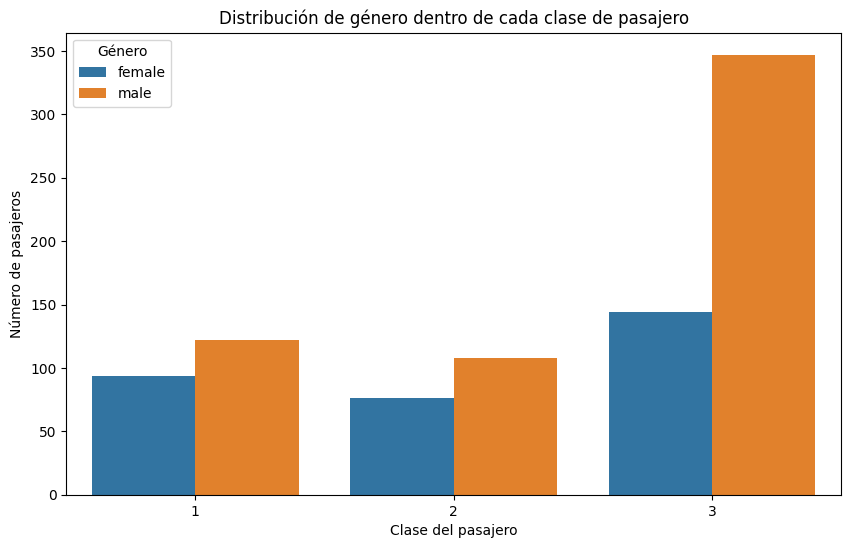

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Pclass', hue='Sex')
plt.title('Distribución de género dentro de cada clase de pasajero')
plt.xlabel('Clase del pasajero')
plt.ylabel('Número de pasajeros')
plt.legend(title='Género')
plt.show()


**Análisis.** En primera y segunda clase la distribución entre hombres y mujeres es relativamente más equilibrada, pero en tercera clase predominan claramente los hombres. En particular, la tercera clase tiene 347 hombres y 144 mujeres. Esta composición puede ayudar a explicar parte de las diferencias observadas en la supervivencia.

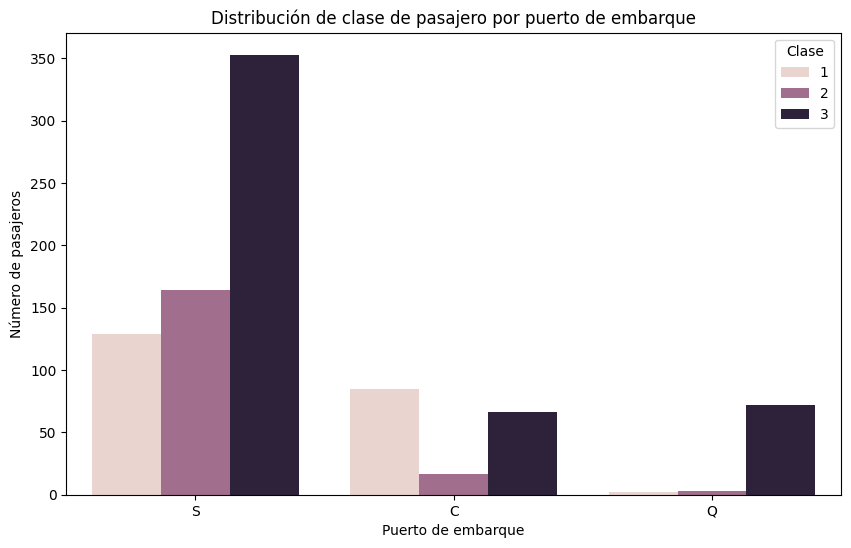

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Embarked', hue='Pclass')
plt.title('Distribución de clase de pasajero por puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Número de pasajeros')
plt.legend(title='Clase')
plt.show()


**Análisis.** Southampton (`S`) concentra la mayor cantidad de pasajeros en las tres clases, especialmente en tercera clase. Cherbourg (`C`) destaca por tener una proporción importante de pasajeros de primera clase, mientras que Queenstown (`Q`) está dominado casi por completo por tercera clase. Esto refuerza la idea de que `Embarked` puede reflejar diferencias socioeconómicas indirectas.

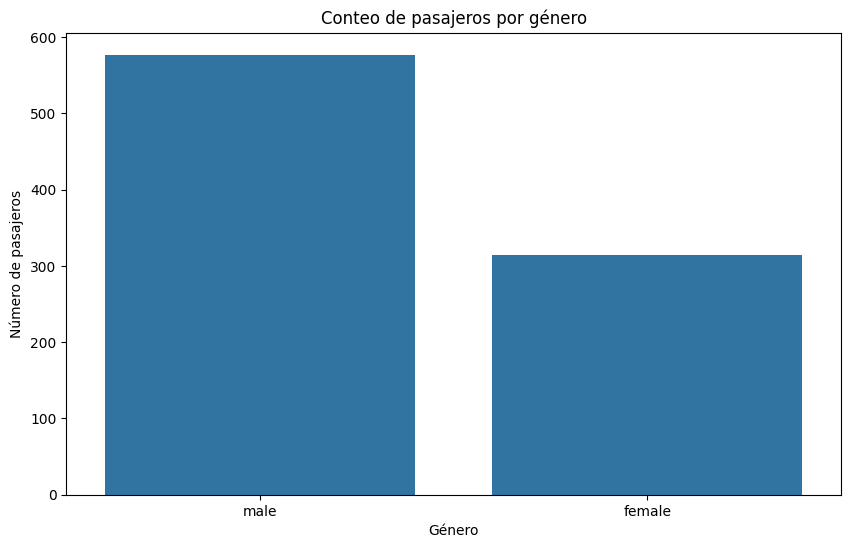

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sex')
plt.title('Conteo de pasajeros por género')
plt.xlabel('Género')
plt.ylabel('Número de pasajeros')
plt.show()


**Análisis.** El conjunto de datos contiene más hombres que mujeres: 577 hombres frente a 314 mujeres. Por lo tanto, el dataset no está balanceado por género. Esta diferencia debe tenerse en cuenta al interpretar las gráficas de supervivencia.

In [22]:
print(f"Edad mínima: {df['Age'].min()}")
print(f"Edad máxima: {df['Age'].max()}")


Edad mínima: 0.42
Edad máxima: 80.0


**Análisis.** La edad mínima registrada es de 0.42 años y la máxima de 80 años. Esto muestra que el rango de edades es bastante amplio. La presencia de infantes y adultos mayores hace especialmente relevante analizar la edad como variable explicativa.

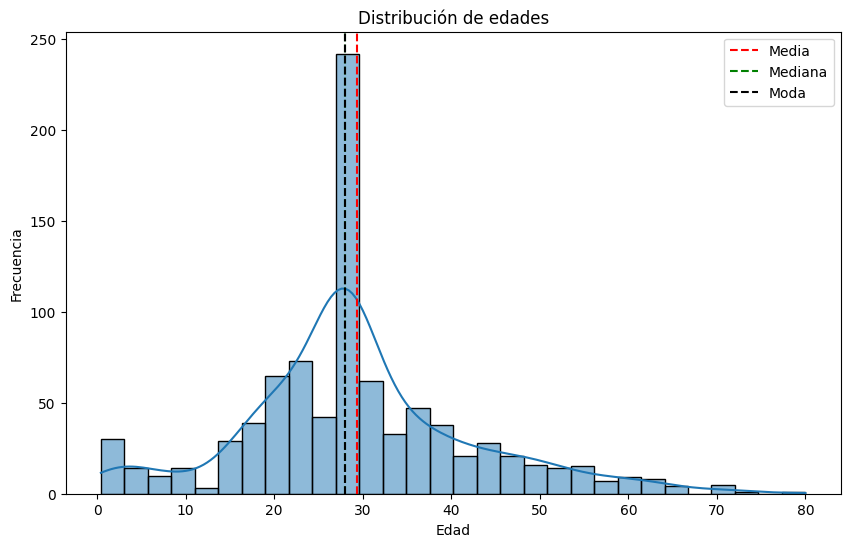

Media: 29.36
Mediana: 28.00
Moda: 28.00


In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', kde=True)
plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Media')
plt.axvline(df['Age'].median(), color='green', linestyle='--', label='Mediana')
plt.axvline(df['Age'].mode()[0], color='black', linestyle='--', label='Moda')

plt.legend()
plt.show()

print(f"Media: {df['Age'].mean():.2f}")
print(f"Mediana: {df['Age'].median():.2f}")
print(f"Moda: {df['Age'].mode()[0]:.2f}")


**Análisis.** La media de edad es 29.36 años, mientras que la mediana y la moda son ambas 28 años. Como la media es ligeramente mayor, la distribución parece presentar un pequeño sesgo hacia la derecha. Esta cercanía entre media y mediana sugiere una distribución relativamente concentrada, aunque con cierta influencia de edades altas.

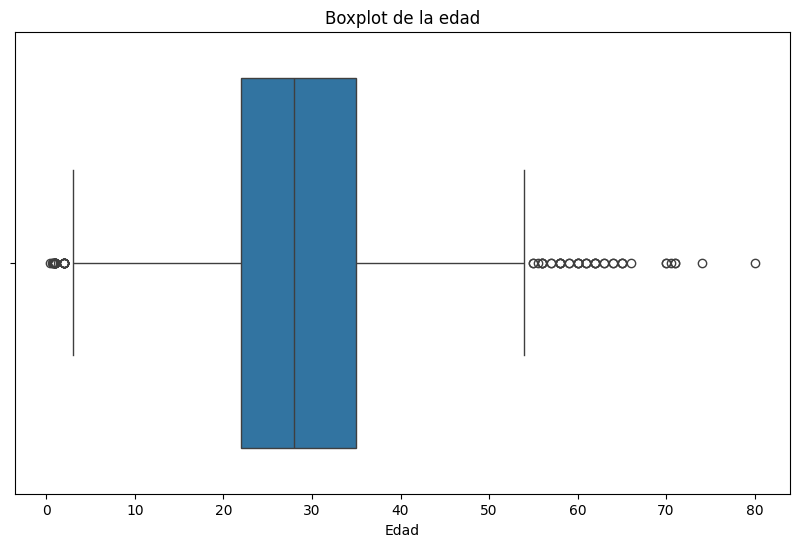

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Age')
plt.title('Boxplot de la edad')
plt.xlabel('Edad')
plt.show()


**Análisis.** El diagrama de caja muestra la presencia de valores atípicos en edades altas. Usando el criterio del rango intercuartílico aparecen 66 posibles outliers por encima del límite superior. Esto indica que, aunque la mayoría de los pasajeros se concentra en edades jóvenes y adultas, también existen varios casos extremos que deben considerarse.

In [25]:
print(f"Tarifa mínima: {df['Fare'].min()}")
print(f"Tarifa máxima: {df['Fare'].max()}")


Tarifa mínima: 0.0
Tarifa máxima: 512.3292


**Análisis.** La tarifa mínima registrada es 0.0 y la máxima 512.3292. La diferencia entre ambos extremos es muy grande, lo que evidencia una fuerte dispersión en esta variable. Esto sugiere que existían diferencias económicas muy marcadas entre los pasajeros.

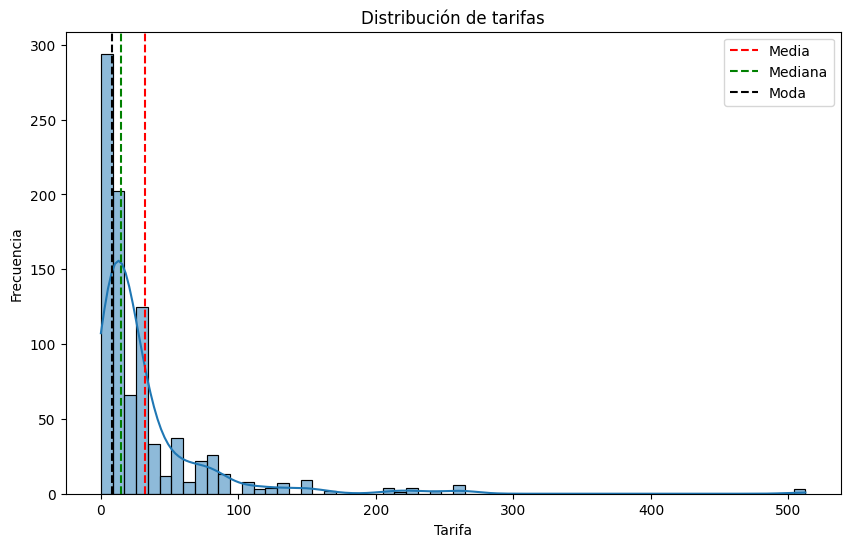

Media: 32.20
Mediana: 14.45
Moda: 8.05


In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Fare', kde=True)
plt.title('Distribución de tarifas')
plt.xlabel('Tarifa')
plt.ylabel('Frecuencia')

plt.axvline(df['Fare'].mean(), color='red', linestyle='--', label='Media')
plt.axvline(df['Fare'].median(), color='green', linestyle='--', label='Mediana')
plt.axvline(df['Fare'].mode()[0], color='black', linestyle='--', label='Moda')

plt.legend()
plt.show()

print(f"Media: {df['Fare'].mean():.2f}")
print(f"Mediana: {df['Fare'].median():.2f}")
print(f"Moda: {df['Fare'].mode()[0]:.2f}")


**Análisis.** La media de la tarifa es 32.20, la mediana 14.45 y la moda 8.05. Como la media es muy superior a la mediana, la distribución está claramente sesgada a la derecha. Esto indica que existen algunas tarifas muy elevadas que empujan la media hacia arriba.

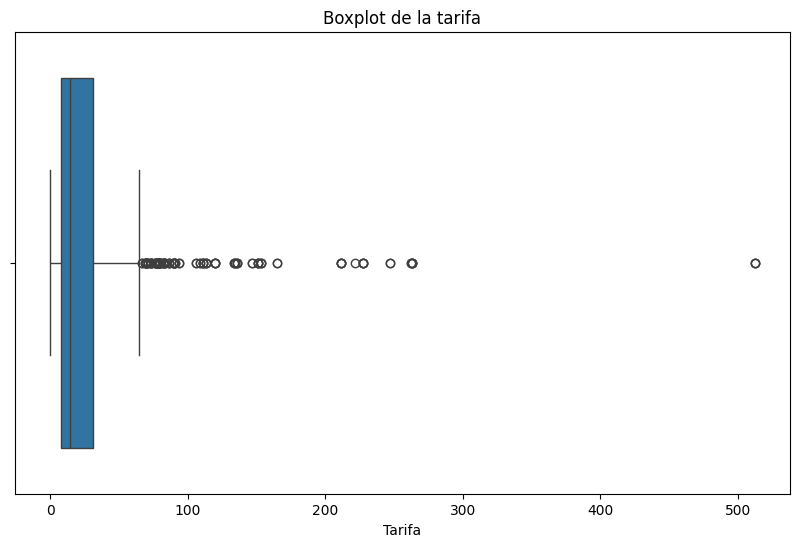

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Fare')
plt.title('Boxplot de la tarifa')
plt.xlabel('Tarifa')
plt.show()


**Análisis.** El boxplot de `Fare` muestra una gran cantidad de valores atípicos altos. Con el criterio del rango intercuartílico se detectan 116 posibles outliers. Esto confirma que la variable tiene una distribución muy asimétrica y que unos pocos pasajeros pagaron tarifas muy superiores al resto.

In [28]:
df[df['Fare'] == 0]


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup
179,0,3,male,36.0,0,0,0.0,S,Adulto
263,0,1,male,40.0,0,0,0.0,S,Adulto
271,1,3,male,25.0,0,0,0.0,S,Joven Adulto
277,0,2,male,28.0,0,0,0.0,S,Joven Adulto
302,0,3,male,19.0,0,0,0.0,S,Joven Adulto
413,0,2,male,28.0,0,0,0.0,S,Joven Adulto
466,0,2,male,28.0,0,0,0.0,S,Joven Adulto
481,0,2,male,28.0,0,0,0.0,S,Joven Adulto
597,0,3,male,49.0,0,0,0.0,S,Adulto
633,0,1,male,28.0,0,0,0.0,S,Joven Adulto


**Análisis.** Se identificaron 15 pasajeros con tarifa igual a cero. De ellos, 14 no sobrevivieron y solo 1 sobrevivió; además, todos eran hombres y todos embarcaron en Southampton. Estos casos son interesantes porque podrían corresponder a situaciones particulares y muestran una supervivencia extremadamente baja.

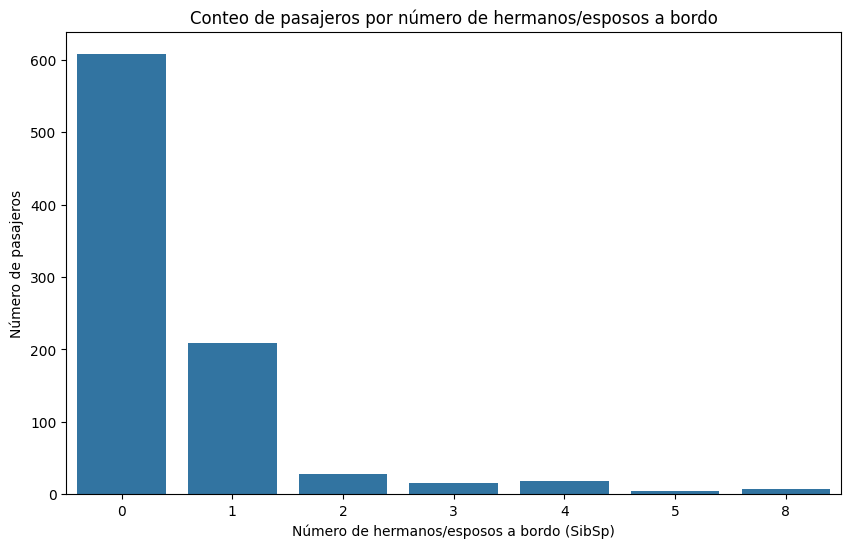

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='SibSp')
plt.title('Conteo de pasajeros por número de hermanos/esposos a bordo')
plt.xlabel('Número de hermanos/esposos a bordo (SibSp)')
plt.ylabel('Número de pasajeros')
plt.show()


**Análisis.** La mayoría de los pasajeros viajaba sin hermanos o esposos a bordo (`SibSp = 0`), con 608 casos. El segundo grupo más frecuente es `SibSp = 1`, con 209 pasajeros. Los valores altos como 5 u 8 son poco comunes, por lo que representan casos excepcionales.

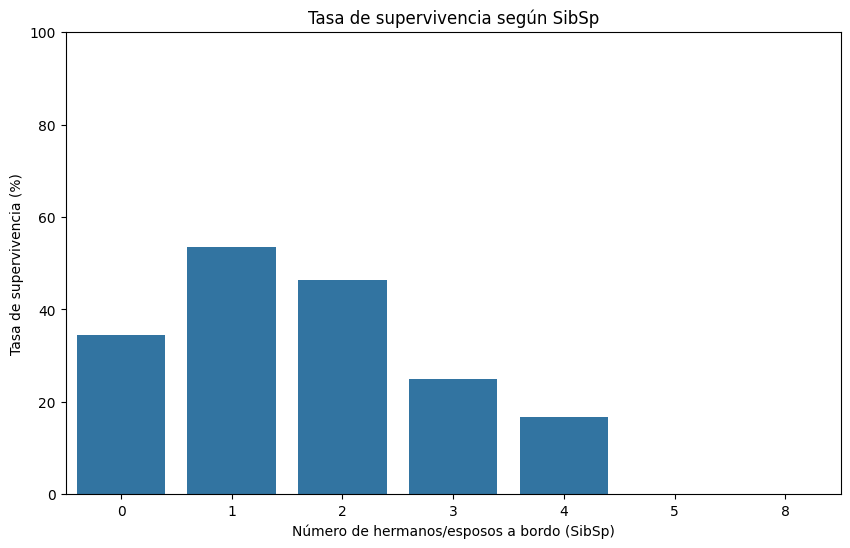

In [30]:
survival_by_sibsp = df.groupby('SibSp')['Survived'].mean() * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=survival_by_sibsp.index, y=survival_by_sibsp.values)
plt.title('Tasa de supervivencia según SibSp')
plt.xlabel('Número de hermanos/esposos a bordo (SibSp)')
plt.ylabel('Tasa de supervivencia (%)')
plt.ylim(0, 100)
plt.show()


**Análisis.** La mayor tasa de supervivencia aparece en los pasajeros con `SibSp = 1`, con 53.59%, seguida por `SibSp = 2`, con 46.43%. En cambio, quienes viajaban con familias muy numerosas presentan tasas muy bajas o nulas. Esto sugiere que viajar acompañado por uno o dos familiares pudo ser favorable, pero viajar con demasiados no.

In [31]:
survival_percentage_sibsp = (df.groupby('SibSp')['Survived'].mean() * 100).round(2)
survival_percentage_sibsp


SibSp
0    34.54
1    53.59
2    46.43
3    25.00
4    16.67
5     0.00
8     0.00
Name: Survived, dtype: float64

**Análisis.** Los porcentajes de supervivencia muestran un patrón no lineal: `0` tiene 34.54%, `1` tiene 53.59%, `2` tiene 46.43%, `3` tiene 25.00%, `4` tiene 16.67%, y `5` y `8` tienen 0.00%. En conjunto, esto indica que una compañía moderada parece asociarse con mejores resultados que viajar solo o en grupos muy grandes.

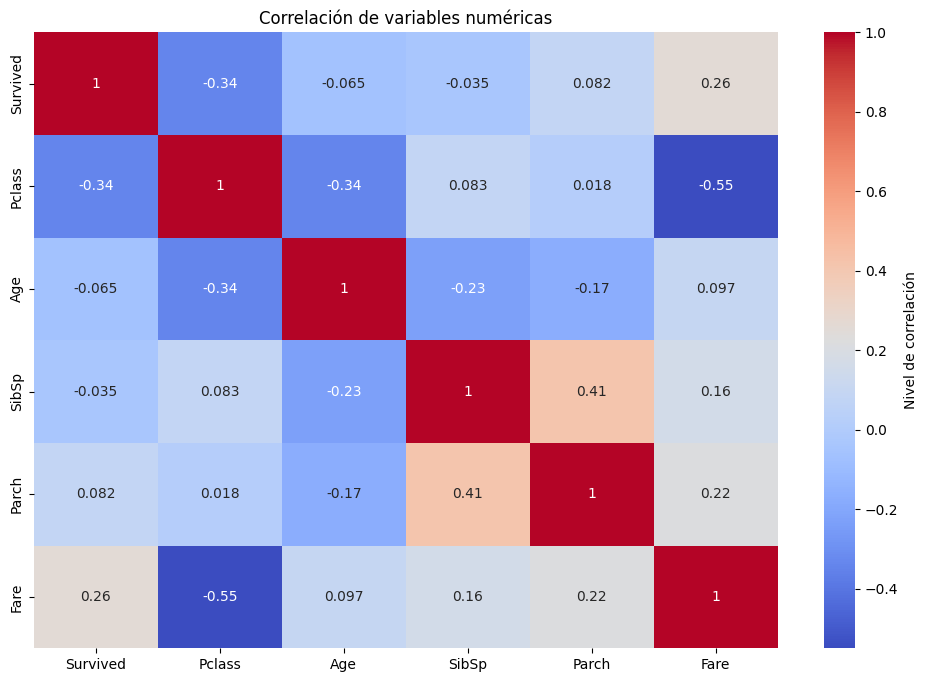

In [32]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(),
    annot=True,
    cmap='coolwarm',
    cbar=True,
    cbar_kws={'label': 'Nivel de correlación'}
)
plt.title('Correlación de variables numéricas')
plt.show()


**Análisis.** La matriz de correlación muestra que `Pclass` tiene una correlación negativa moderada con `Survived` (-0.338), lo que indica que a mayor número de clase, menor probabilidad de supervivencia. `Fare` presenta una correlación positiva con `Survived` (0.257), mientras que `Age`, `SibSp` y `Parch` muestran relaciones lineales débiles. Esto sugiere que algunas variables pueden influir en la supervivencia, pero no siempre de forma estrictamente lineal.